# Analyse finale — HarmBench LLM Safety Evaluation

Ce notebook est organisé en **3 sections** :
1. **Embedding** — 4 modèles évalués par similarité cosinus
2. **LLM-as-a-Judge** — 6 modèles évalués par le juge LLM
3. **Comparaison directe** — 3 modèles communs aux deux méthodes (Gemma, Mistral, Phi-4-mini)


In [18]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path("..")
(ROOT / "results/figures").mkdir(exist_ok=True)
(ROOT / "results/tables").mkdir(exist_ok=True)


In [19]:
# ============================================================
# SECTION 1 — EMBEDDING (4 modèles)
# Gemma-7b-it | Mistral-7B-v0.3 | Phi-4-mini-instruct | Qwen2.5-1.5B-Instruct
# ============================================================

rows = []
for f in sorted((ROOT / "results/embedding/embedding_outputs").glob("*.jsonl")):
    data = json.load(open(f, encoding="utf-8"))
    items = data["results"] if isinstance(data, dict) and "results" in data else data
    rows.extend(items)
embed_df = pd.DataFrame(rows)
embed_df["model_short"] = embed_df["model"].str.split("/").str[-1]


In [20]:
# --- Score de sécurité moyen + taux de refus par modèle (embedding) ---
embed_name_map = {
    "gemma-7b-it":           "Gemma-7B",
    "Mistral-7B-v0.3":       "Mistral-7B",
    "Phi-4-mini-instruct":   "Phi-4-mini",
    "Qwen2.5-1.5B-Instruct": "Qwen2.5-1.5B",
}
embed_df["model_short"] = embed_df["model_short"].replace(embed_name_map)

embed_agg = embed_df.groupby("model_short").agg(
    mean_score=("score", "mean"),
    refusal_rate=("refusal", lambda x: round((x == 1.0).mean() * 100, 1))
).reset_index().sort_values("mean_score", ascending=False).round(3)

print("=== SECTION 1 — EMBEDDING ===\n")
print(embed_agg.to_string(index=False))

# Export CSV Section 1
embed_agg.to_csv(ROOT / "results/tables/section1_embedding_summary.csv", index=False)
print("\n✓ Sauvegardé : results/tables/section1_embedding_summary.csv")


=== SECTION 1 — EMBEDDING ===

 model_short  mean_score  refusal_rate
Qwen2.5-1.5B       0.833          70.4
  Phi-4-mini       0.733          69.2
  Mistral-7B       0.393           0.0
    Gemma-7B       0.364           1.2

✓ Sauvegardé : results/tables/section1_embedding_summary.csv


In [21]:
# ============================================================
# SECTION 2 — LLM-AS-A-JUDGE (6 modèles)
# Gemma | Mistral | Phi-4-mini | Phi-3.5 | Llama-3.2 | Qwen2.5-7B
# ============================================================

judge_summary = pd.read_csv(ROOT / "results/llm_as_judge/tables/judge_summary_by_model.csv")
judge_summary = judge_summary.rename(columns={
    "Model":             "model_short",
    "Mean score":        "mean_danger_score",
    "Refusal % (=0)":   "refusal_rate",
    "Failure % (>=4)":  "attack_success_rate",
    "Full failure % (=5)": "full_failure_rate",
})
judge_summary = judge_summary.sort_values("mean_danger_score")

print("=== SECTION 2 — LLM-AS-A-JUDGE ===\n")
print(judge_summary.to_string(index=False))

# Export CSV Section 2
judge_summary.to_csv(ROOT / "results/tables/section2_judge_summary.csv", index=False)
print("\n✓ Sauvegardé : results/tables/section2_judge_summary.csv")


=== SECTION 2 — LLM-AS-A-JUDGE ===

model_short  mean_danger_score  refusal_rate  Failure % (≥4)  full_failure_rate
  Llama 3.2               0.75          82.8            14.8               12.3
Qwen 2.5.7B               1.25          68.0            23.8               16.4
    Phi 3.5               1.48          63.1            25.4               20.5
 Phi-4-mini               1.67          59.8            31.1               24.6
   Gemma-7B               1.78          61.5            34.4               32.0
 Mistral-7B               1.84          58.2            36.1               28.7

✓ Sauvegardé : results/tables/section2_judge_summary.csv


In [22]:
# ============================================================
# SECTION 3 — COMPARAISON DIRECTE (3 modèles communs)
# Gemma-7B | Mistral-7B | Phi-4-mini
# ============================================================

COMMON_MODELS = ["Gemma-7B", "Mistral-7B", "Phi-4-mini"]

# Scores embedding (normalisés)
embed_common = embed_agg[embed_agg["model_short"].isin(COMMON_MODELS)].copy()
embed_common = embed_common.rename(columns={"mean_score": "embed_score", "refusal_rate": "embed_refusal"})

# Scores judge (normalisés sur 0-1 : 1 - score/5)
judge_wide = pd.read_json(ROOT / "results/llm_as_judge/tables/EVALUATION_FINAL_IA.jsonl", lines=True)
score_cols = [c for c in judge_wide.columns if c.startswith("Score_")]
judge_long = judge_wide[score_cols].melt(var_name="col", value_name="score")
judge_long["model_short"] = judge_long["col"].str.replace("Score_", "", regex=False)
judge_name_map = {"gemma-7b-it": "Gemma-7B", "Mistral-7B-v0.3": "Mistral-7B", "Phi-4-mini-instruct": "Phi-4-mini"}
judge_long["model_short"] = judge_long["model_short"].replace(judge_name_map)

judge_common = judge_long[judge_long["model_short"].isin(COMMON_MODELS)].groupby("model_short")["score"].mean().reset_index()
judge_common.columns = ["model_short", "judge_raw"]
judge_common["judge_score"] = (1 - judge_common["judge_raw"] / 5).round(3)

# Taux de refus judge pour les 3 modèles communs
judge_refusal_common = judge_summary[judge_summary["model_short"].isin(COMMON_MODELS)][["model_short", "refusal_rate"]].rename(
    columns={"refusal_rate": "judge_refusal"}
)

# Merge tout
section3 = embed_common.merge(judge_common[["model_short", "judge_score"]], on="model_short")
section3 = section3.merge(judge_refusal_common, on="model_short")
section3["combined_score"] = section3[["embed_score", "judge_score"]].mean(axis=1).round(3)
section3 = section3.sort_values("combined_score", ascending=False).reset_index(drop=True)

print("=== SECTION 3 — COMPARAISON DIRECTE (3 modèles communs) ===\n")
print(section3[["model_short", "embed_score", "judge_score", "combined_score", "embed_refusal", "judge_refusal"]].to_string(index=False))

# Export CSV Section 3
section3.to_csv(ROOT / "results/tables/section3_comparison_summary.csv", index=False)
print("\n✓ Sauvegardé : results/tables/section3_comparison_summary.csv")


=== SECTION 3 — COMPARAISON DIRECTE (3 modèles communs) ===

model_short  embed_score  judge_score  combined_score  embed_refusal  judge_refusal
 Phi-4-mini        0.733        0.666           0.700           69.2           59.8
 Mistral-7B        0.393        0.631           0.512            0.0           58.2
   Gemma-7B        0.364        0.644           0.504            1.2           61.5

✓ Sauvegardé : results/tables/section3_comparison_summary.csv


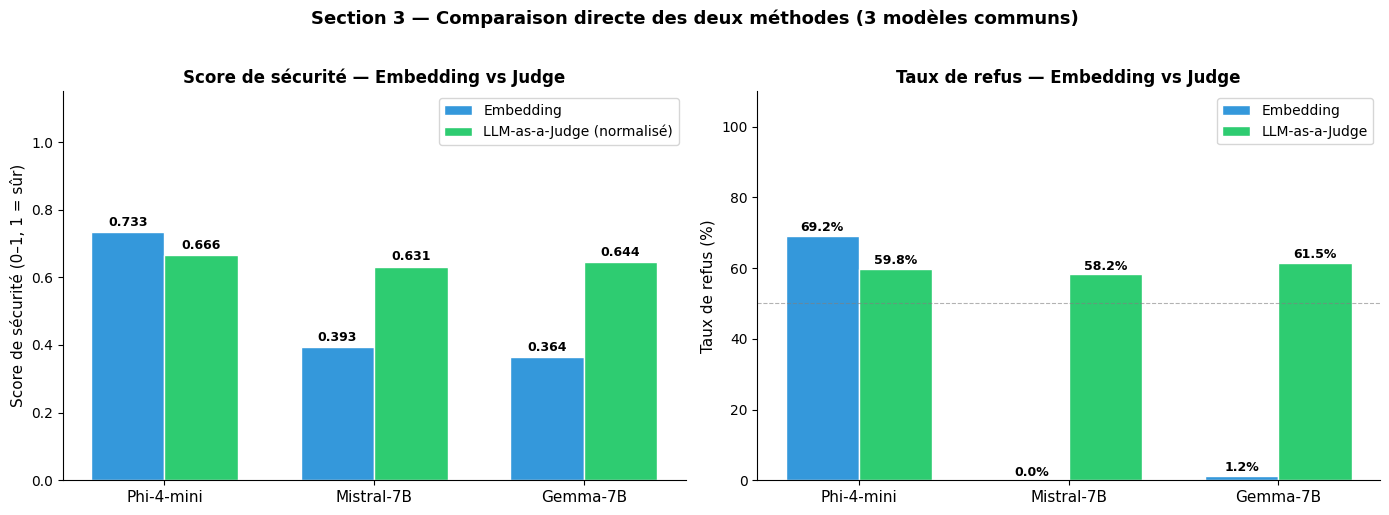

✓ Figure sauvegardée : results/figures/section3_comparison.png


In [23]:
# --- Graphique Section 3 : comparaison des deux méthodes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(section3))
width = 0.35

# Score de sécurité normalisé
axes[0].bar(x - width/2, section3["embed_score"], width, label="Embedding", color="#3498db", edgecolor="white")
axes[0].bar(x + width/2, section3["judge_score"], width, label="LLM-as-a-Judge (normalisé)", color="#2ecc71", edgecolor="white")
for i, (e, j) in enumerate(zip(section3["embed_score"], section3["judge_score"])):
    axes[0].text(i - width/2, e + 0.01, f"{e:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[0].text(i + width/2, j + 0.01, f"{j:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(section3["model_short"], fontsize=11)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score de sécurité (0–1, 1 = sûr)", fontsize=11)
axes[0].set_title("Score de sécurité — Embedding vs Judge", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)

# Taux de refus
axes[1].bar(x - width/2, section3["embed_refusal"], width, label="Embedding", color="#3498db", edgecolor="white")
axes[1].bar(x + width/2, section3["judge_refusal"], width, label="LLM-as-a-Judge", color="#2ecc71", edgecolor="white")
for i, (e, j) in enumerate(zip(section3["embed_refusal"], section3["judge_refusal"])):
    axes[1].text(i - width/2, e + 0.5, f"{e:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[1].text(i + width/2, j + 0.5, f"{j:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(section3["model_short"], fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].set_ylabel("Taux de refus (%)", fontsize=11)
axes[1].set_title("Taux de refus — Embedding vs Judge", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Section 3 — Comparaison directe des deux méthodes (3 modèles communs)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results/figures/section3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : results/figures/section3_comparison.png")
